# Behavioural analysis

All the analysis code lives in the `ppsanalysis` package. This notebook only
**drives** it: load the data, build the shared tables, run each hypothesis, read
the results.

```
ppsanalysis/
  config.py        paths, subject metadata, RT window, seeds, thresholds
  figures.py       publication-grade SVG settings and helpers
  io.py            Unity export loading and tidying
  qc.py            trial usability and data-quality checks
  stats_utils.py   sigmoid/AIC fits, bootstrap, permutation, classification
  pps.py           facilitation, near-far index, sigmoid boundary, Delta_PPS
  collision.py     PSE, Delta_coll, carryover, accuracy
  permutations.py  label-shuffling nulls for the single-case tests
  tables.py        the shared derived tables, built once
  hypotheses/
```

Every hypothesis module has a `run(t)` function, a `report()` that prints the
numbers, and a `make_figure()` that draws them. Open any of them and read it
top to bottom: they are written as a sequence of numbered steps, and each step
says why it is there.

**Figures.** Every figure is saved as an editable SVG (and a PDF) in `figures/`.
They are drawn at real journal column width, so the font sizes are already correct
and you must not resize them afterwards.

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import style
style.apply()

import ppsanalysis as pa
from ppsanalysis import config, figures
from ppsanalysis.hypotheses import h1, h1a, h2, h3, h4, h5, h6, h7a, h7b

# Publication-grade defaults: vector SVG, editable text, bold titles,
# journal-sized fonts, no top/right frame lines.
figures.apply()
figures.FIGURE_DIR = "figures"

pd.set_option("display.max_columns", 120)

## 0.1 Configuration

In [2]:
config.PILOT_DATA_DIR = "/Users/pamelavandenenden/Desktop/PPS/05_analysis/data/behavior"
config.OUT_DIR = "."

config.RT_MIN_MS = 100
config.RT_MAX_MS = 900
config.DROP_POSITIONS = ()         

config.YOUNG_CONTROL_SUBJECTS = ["franc", "theo"]
config.PATIENT_ID = "theo"
config.MATCHED_CONTROL_ID = None

config.N_BOOT = 5000
config.RANDOM_SEED = 123

## 1. Load the data and build the shared tables

In [3]:
pps_trials, collision_trials, subjects = pa.io.make_analysis_csvs(
    data_dir=config.PILOT_DATA_DIR,
    out_dir=config.OUT_DIR,
)

pps_trials = pa.qc.mark_pps_usable(
    pps_trials,
    rt_min_ms=config.RT_MIN_MS,
    rt_max_ms=config.RT_MAX_MS,
    drop_positions=config.DROP_POSITIONS,
)

t = pa.tables.build(pps_trials, collision_trials, subjects)
pa.tables.describe(t)

Trial files found: 4
 - sub-franc-task2_session-1_task2_trials.csv | folder: franc-task2_s1
 - sub-franc_session-1_task1_trials.csv | folder: franc_s1
 - sub-theo_session-1_task2_trials.csv | folder: theo_s1-task2
 - sub-theo_session-1_task1_trials.csv | folder: theo_s1
Loaded from:  /Users/pamelavandenenden/Desktop/PPS/05_analysis/data/behavior
Saved CSVs to: .
PPS trials       :   882  (685 usable)
Collision trials :   324  (324 usable)
Young controls   : ['franc', 'theo']
RT window        : 100-900 ms
Dropped positions: none
Clinical pair    : patient=theo, control=franc


## 1.1 Data quality

In [4]:
pa.qc.quick_qc(t.pps_trials, t.collision_trials)

,dataset,rows,usable,excluded,usable_%
0,PPS,882,685,197,77.7
1,Hit/Miss,324,324,0,100.0


=== PPS trial counts ===


subject,Slow T,Slow VT,Slow V,Fast T,Fast VT,Fast V,total
franc,42,126,42,42,126,42,420
theo,84,126,21,84,126,21,462
all,126,252,63,126,252,63,882



=== Hit/Miss trial counts ===


subject,Slow Near Hit,Slow Near Miss,Slow Clear Hit,Slow Clear Miss,Fast Near Hit,Fast Near Miss,Fast Clear Hit,Fast Clear Miss,total
franc,22,28,17,17,31,27,11,12,165
theo,22,30,13,14,24,19,20,17,159
all,44,58,30,31,55,46,31,29,324



=== PPS RT contrast (T vs VT) ===
saved: figures/quick_qc/pps_rt_contrast_T_vs_VT.png


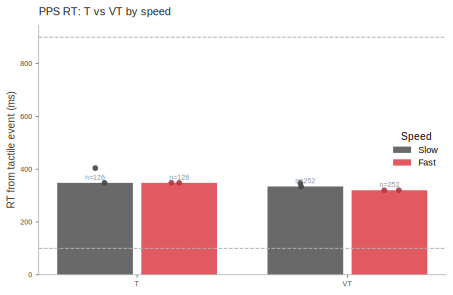


=== Hit/Miss accuracy by trial type ===
saved: figures/quick_qc/collision_accuracy_by_type.png


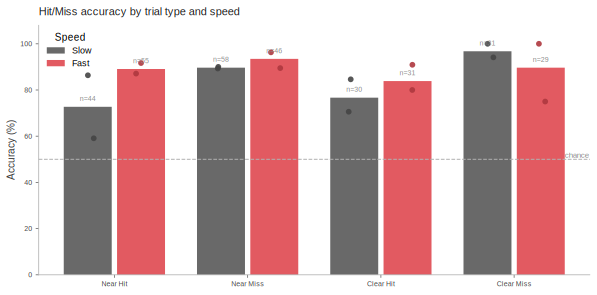

In [5]:
from ppsanalysis import quick_behavior_plots as qbp

quick_qc = qbp.run(
    t,
    rt_min=config.RT_MIN_MS,
    rt_max=config.RT_MAX_MS,
    save_dir="figures/quick_qc",
    show=True,
)

# Aim 1 — The PPS effect in young healthy controls

## H1. Facilitation increases as the stimulus approaches

Supported if the bootstrap 95% CI on the near-far index lies entirely above zero.

H1, step 1: facilitation (ms) at each distance
  rows = distance rank, 1 = closest to the body
  positive = the visual stimulus made the person faster

subject        franc  theo
position_rank             
1.0              3.9  17.1
2.0             79.8   0.0
3.0             13.3  20.8
4.0            -13.7   6.9
5.0            -14.3  35.0
6.0             34.8  14.1
7.0              NaN  49.2

H1, step 2: near-far index per participant
  near = D1 and D2, far = D6 and D7

subject  near_mean  far_mean  nearfar_pps
  franc      41.81     10.20        31.61
   theo       8.55     31.66       -23.11

H1, step 3: group test on the near-far index
  number of participants  = 2
  mean NearFar_PPS        = 4.25 ms
  bootstrap 95% CI        = [-23.11, 31.61] ms
  Wilcoxon (one-sided)    = W 2.0, p 0.5000

  The bootstrap CI decides support. The Wilcoxon is a sensitivity check only.

  H1 is NOT supported: the 95% CI includes zero.
  saved: figures/h1_facilitation.svg
  saved: figures/h1_facilitat

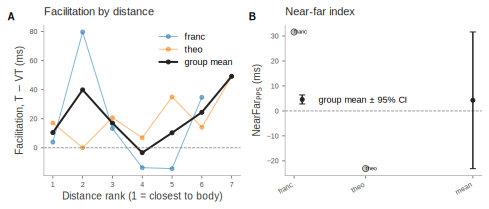

In [11]:
r_h1 = h1.run(t)

## H1a. The facilitation profile is sigmoidal

A sigmoid implies a *boundary*. A straight line does not. This compares flat,
linear and sigmoid fits by AIC.

Distance ranks present in the data: 1 to 7

H1a: model comparison for each participant
  lower AIC = better fit

subject  aic_flat  aic_linear  aic_sigmoid  x_c     k preferred  sigmoid_lower_aic
  franc     62.83       64.49        66.70 2.96 21.43      flat              False
   theo     62.27       60.61        63.79 4.51 26.11      flat              False

H1a: group-averaged profile (descriptive)

aic_flat        63.445
aic_linear      64.627
aic_sigmoid     64.622
x_c              6.015
k              -64.724
preferred         flat

H1a verdict (preregistered criterion):
  sigmoid AIC lower than BOTH flat and linear in 0 of 2 participants

H1a extra (stricter, descriptive):
  sigmoid also wins by a margin of 2.0, with a boundary
  inside the tested range, in 0 of 2 participants
  saved: figures/h1a_sigmoid_shape.svg
  saved: figures/h1a_sigmoid_shape.pdf


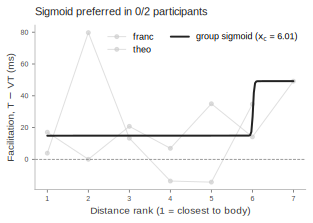

In [10]:
r_h1a = h1a.run(t)

## H2. The PPS boundary moves outward for faster approach

Note that H2 refuses to draw a sigmoid whose inflection falls outside the tested
range, or whose slope is implausible. If it says the fit was rejected, then
Delta_PPS is not measuring a boundary shift and H2 cannot be interpreted.

H2, step 1: Delta_PPS per participant
  Delta_PPS = x_c(fast) - x_c(slow). Positive = boundary moved outward.

subject  delta_pps
  franc      0.417
   theo     -1.022

H2, step 2: group test
  number of participants  = 2
  mean Delta_PPS          = -0.302
  bootstrap 95% CI        = [-1.022, 0.417]
  Wilcoxon (one-sided)    = W 1.0, p 0.7500

  H2 is NOT supported.

  A rejected fit means the boundary fell outside the tested range, or the
  slope was implausible. If this happens, Delta_PPS is not measuring a
  boundary shift, and H2 cannot be interpreted. Check the raw profile.
  saved: figures/h2_delta_pps.svg
  saved: figures/h2_delta_pps.pdf


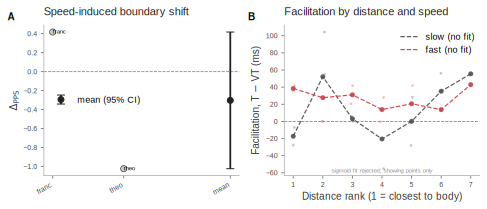

In [9]:
r_h2 = h2.run(t)

## H3. The collision boundary shifts with ball speed

H3, step 1: Delta_coll per participant
  Delta_coll = PSE(fast) - PSE(slow), in cm.
  Positive = the collision boundary moved outward for a fast ball.

subject  delta_coll
  franc        2.46
   theo      -12.08

H3, step 2: group test
  number of participants  = 2
  mean Delta_coll         = -4.81 cm
  bootstrap 95% CI        = [-12.08, 2.46] cm
  Wilcoxon (one-sided)    = W 1.0, p 0.7500

  H3 is NOT supported.
  saved: figures/h3_delta_coll.svg
  saved: figures/h3_delta_coll.pdf


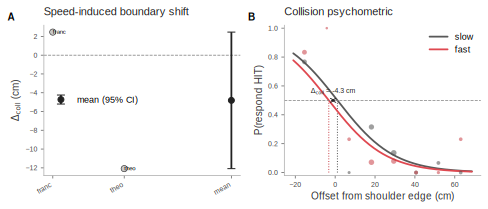

In [8]:
r_h3 = h3.run(t)

# Aim 2 — PPS and its recalibration in Parkinson's disease

These need one patient and one matched control. Without them each cell prints
that it is skipped and returns `{"skipped": True}`, so the notebook still runs
top to bottom on pilot data.

## H4. Does the patient show distance-dependent facilitation at all?

Patient:         theo
Matched control: franc

Patient PPS sessions available: [np.int64(1)]

H4: near-far index in the patient, tested against a shuffled-distance null

 session  n_usable_trials  observed_nearfar_ms  permutation_p  n_permutations  supported
       1              408             -23.1125         0.8292            5000      False

  H4  is NOT supported in every session.
  saved: figures/h4_patient_nearfar.svg
  saved: figures/h4_patient_nearfar.pdf


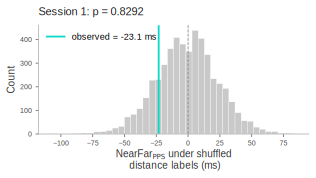

In [6]:
r_h4= h4.run(t)

## H5. Is the patient's speed recalibration altered?

Two tests, and the second is **gated** on the first. If the patient shows no
recalibration signal at all (Test A), comparing their Delta_PPS to a control's
would just be comparing noise, so Test B is not run.

H6 also chooses which patient session to use. **H7 and H8b both depend on that
choice**, so it is handed over explicitly below.

  Falling back to session 1, which may NOT be the

Patient session (high dopamine): 1
Control session:                 1

Patient Delta_PPS = -1.022
Control Delta_PPS = 0.417
Observed D_PPS    = -1.440   (patient minus control)

--- Test A: does the patient show any Delta_PPS? ---
  observed Delta_PPS = -1.022
  permutation p      = 0.6583
  Test A supported   = False

Test A did not pass, so Test B is NOT run.
  Without a recalibration signal in the patient, comparing their
  Delta_PPS to the control's would just be comparing noise.
  saved: figures/h5_patient_recalibration.svg
  saved: figures/h5_patient_recalibration.pdf


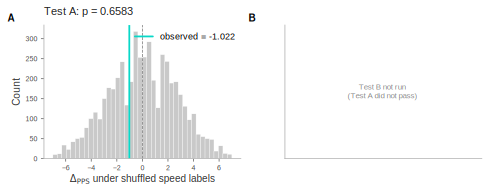


sessions carried forward: patient=1, control=1


In [7]:
r_h5 = h5.run(t)

t.patient_session = r_h5.get("PATIENT_SESSION_USED")
t.control_session = r_h5.get("CONTROL_SESSION_USED", 1)
print(f"\nsessions carried forward: patient={t.patient_session}, control={t.control_session}")

## H6. Is the patient's collision-boundary shift altered?

Patient session: 1
Control session: 1

Patient Delta_coll = -12.08 cm
Control Delta_coll = 2.46 cm
Observed D_coll    = -14.54 cm

--- Test A: does the patient show any Delta_coll? ---
  observed Delta_coll = -12.08 cm
  permutation p       = 0.9784
  Test A supported    = False

Test A did not pass, so Test B is NOT run.
  saved: figures/h6_patient_collision.svg
  saved: figures/h6_patient_collision.pdf


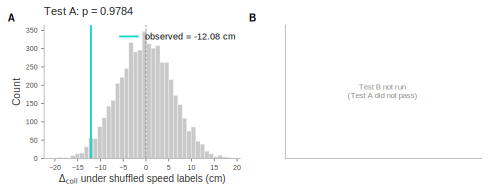

In [12]:
r_h6 = h6.run(t)

# Aim 3 — PPS plasticity and Hit-or-Miss judgment

## H7a. Across young controls

Exact permutation Spearman correlations. 

H7a data table (one row per young control):

subject  delta_pps  delta_coll  accuracy  near_boundary_accuracy  carryover_cm
  franc      0.417       2.457     0.873                   0.898         4.703
   theo     -1.022     -12.082     0.862                   0.832         1.384

Number of participants with both tasks: 2

H7a.1: Delta_PPS with Delta_coll (predicted POSITIVE)
  n                = 2
  Spearman rho     = nan
  exact p (greater) = nan
  supported        = False

H7a.2: Delta_PPS with near-boundary accuracy (PRIMARY, predicted POSITIVE)
  n                = 2
  Spearman rho     = nan
  exact p (greater) = nan
  supported        = False

H7a.2: Delta_PPS with overall accuracy (descriptive only)
  n                = 2
  Spearman rho     = nan
  exact p (greater) = nan
  supported        = False

H7a.3: Delta_PPS with carryover (predicted NEGATIVE)
  n                = 2
  Spearman rho     = nan
  exact p (less   ) = nan
  supported        = False

  saved: figures/h7a_corre

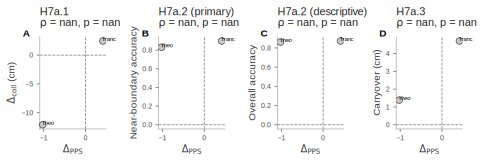

In [13]:
r_h7a = h7a.run(t)

## H7b. In the patient-control pair

Uses a **joint sign criterion**, not two separate tests. Two measures can each be
negative 96% of the time while being negative *together* only 60% of the time.
Since the claim is a co-occurrence, we measure the co-occurrence directly.

This needs H6's bootstrap, paired on the bootstrap index, which is why `r_h5` is
passed in rather than recomputed.

In [ ]:
r_h7b = h7b.run(t, r_h5)

H7b: observed deviations (patient minus control)

    measure  patient  control  difference
      D_PPS   -1.022    0.417      -1.440
     D_coll  -12.082    2.457     -14.539
      D_acc    0.862    0.873      -0.011
  D_nearacc    0.832    0.898      -0.067
D_carryover    1.384    4.703      -3.319

H7b: no PPS bootstrap available (H6 Test A did not pass), so the
  paired bootstrap cannot be built and H7b cannot run.


## Summary

In [ ]:
summary = pd.DataFrame([
    {"hypothesis": "H1",  "outcome": r_h1["supported"]},
    {"hypothesis": "H1a", "outcome": f"{r_h1a['n_supported']}/{r_h1a['n_total']} participants"},
    {"hypothesis": "H2",  "outcome": r_h2["supported"]},
    {"hypothesis": "H3",  "outcome": r_h3["supported"]},
    {"hypothesis": "H5",  "outcome": r_h5.get("h5_supported_overall", "skipped")},
    {"hypothesis": "H6",  "outcome": r_h6.get("h6_classification", "skipped")},
    {"hypothesis": "H8a.1", "outcome": r_h7a["h7a_1"]["supported"]},
    {"hypothesis": "H8a.2", "outcome": r_h7a["h7a_2_near"]["supported"]},
    {"hypothesis": "H8a.3", "outcome": r_h7a["h7a_3"]["supported"]},
])
summary